# GNN_training

In [1]:
from pathlib import Path
import pickle
import torch
import networkx as nx

# Chemin du graphe : même dossier que le notebook (après pull) ou chemin serveur
base_dir = Path(".").resolve()
graph_path = base_dir / "graph_focus_zone.pkl"
if not graph_path.exists():
    graph_path = Path("/users/eleves-b/2023/marc.saade/bachelor-thesis/thesis") / "graph_focus_zone.pkl"

print("Loading graph from:", graph_path)
with open(graph_path, "rb") as f:
    G = pickle.load(f)

print(f"G: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")

# Nombre de "branchements" (nœuds avec plus d'un arc sortant)
out_deg = dict(G.out_degree())
branching_nodes = [n for n in G.nodes() if out_deg.get(n, 0) > 1]
print(f"Nœuds avec au moins 2 arcs sortants (branchements): {len(branching_nodes):,}")

Loading graph from: /users/eleves-b/2023/marc.saade/bachelor-thesis/thesis/graph_focus_zone.pkl
G: 623,661 nodes, 1,250,088 edges
Nœuds avec au moins 2 arcs sortants (branchements): 294,182


In [2]:
from math import radians, sin, cos, sqrt, atan2

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    return R * c

MAX_SEGMENT_KM = 200.0  # seuil pour couper les sauts non physiques (comme traverser la Floride)

to_remove = []
for u, v in G.edges():
    lat1, lon1 = G.nodes[u]["lat"], G.nodes[u]["lon"]
    lat2, lon2 = G.nodes[v]["lat"], G.nodes[v]["lon"]
    seg_dist = haversine_km(lat1, lon1, lat2, lon2)
    if seg_dist > MAX_SEGMENT_KM:
        to_remove.append((u, v))

print(f"Removing {len(to_remove):,} edges with segment distance > {MAX_SEGMENT_KM} km")
G.remove_edges_from(to_remove)
print(f"Remaining edges: {G.number_of_edges():,}")

# Garder UNIQUEMENT la plus grande composante connexe -> tout couple de nœuds a un chemin
wcc = list(nx.weakly_connected_components(G))
largest = max(wcc, key=len)
G = G.subgraph(largest).copy()
print(f"Largest component: {len(largest):,} nodes. G = {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")

Removing 3,898 edges with segment distance > 200.0 km
Remaining edges: 1,246,190
Largest component: 485,977 nodes. G = 485,977 nodes, 1,017,453 edges


In [3]:
# Conversion en PyG et construction des features nœuds
from torch_geometric.data import Data
from torch_geometric.utils import from_networkx

node_attrs = ["lat", "lon"]
data = from_networkx(G, group_node_attrs=node_attrs)

x = data.x  # [N, 2]
edge_index = data.edge_index
num_nodes = data.num_nodes

# Degré entrant / sortant comme features supplémentaires
deg_out = torch.zeros(num_nodes, dtype=torch.float32)
deg_in = torch.zeros(num_nodes, dtype=torch.float32)
ones = torch.ones(edge_index.size(1), dtype=torch.float32)
deg_out.index_add_(0, edge_index[0], ones)
deg_in.index_add_(0, edge_index[1], ones)

data.x = torch.cat([x, torch.log1p(deg_in).unsqueeze(1), torch.log1p(deg_out).unsqueeze(1)], dim=1)
print("Node features shape:", data.x.shape)

Node features shape: torch.Size([485977, 4])


In [4]:
# Split train/val/test pour link prediction
from torch_geometric.transforms import RandomLinkSplit

transform = RandomLinkSplit(num_val=0.1, num_test=0.1, is_undirected=False, add_negative_train_samples=True)
train_data, val_data, test_data = transform(data)

print("Train edge_label_index:", train_data.edge_label_index.shape)
print("Val/Test splits done.")

Train edge_label_index: torch.Size([2, 1627926])
Val/Test splits done.


In [5]:
# Modèle GNN : encodeur + score de lien
from torch import nn
from torch_geometric.nn import GCNConv

class GCNLinkPredictor(nn.Module):
    def __init__(self, in_channels, hidden=64):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.dropout = nn.Dropout(0.2)
        self.mlp = nn.Sequential(
            nn.Linear(2 * hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
        )

    def encode(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, z, edge_label_index):
        z_src = z[edge_label_index[0]]
        z_dst = z[edge_label_index[1]]
        return self.mlp(torch.cat([z_src, z_dst], dim=-1)).squeeze(-1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GCNLinkPredictor(in_channels=train_data.x.size(-1)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

In [6]:
# Boucle d'entraînement
from sklearn.metrics import roc_auc_score

def train_step(data):
    model.train()
    optimizer.zero_grad()
    x = data.x.to(device)
    edge_index = data.edge_index.to(device)
    edge_label_index = data.edge_label_index.to(device)
    edge_label = data.edge_label.to(device).float()
    z = model.encode(x, edge_index)
    logits = model.decode(z, edge_label_index)
    loss = criterion(logits, edge_label)
    loss.backward()
    optimizer.step()
    return loss.item()

def eval_auc(data):
    model.eval()
    x = data.x.to(device)
    edge_index = data.edge_index.to(device)
    edge_label_index = data.edge_label_index.to(device)
    edge_label = data.edge_label.cpu().numpy()
    with torch.no_grad():
        z = model.encode(x, edge_index)
        logits = model.decode(z, edge_label_index)
        probs = torch.sigmoid(logits).cpu().numpy()
    return roc_auc_score(edge_label, probs)

EPOCHS = 30
for epoch in range(1, EPOCHS + 1):
    loss = train_step(train_data)
    val_auc = eval_auc(val_data)
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d} loss={loss:.4f} val_AUC={val_auc:.4f}")

test_auc = eval_auc(test_data)
print(f"Test AUC: {test_auc:.4f}")

Epoch 01 loss=2.0536 val_AUC=0.6016
Epoch 05 loss=1.1230 val_AUC=0.5770
Epoch 10 loss=0.9297 val_AUC=0.6041
Epoch 15 loss=0.7893 val_AUC=0.5595
Epoch 20 loss=0.7079 val_AUC=0.4678
Epoch 25 loss=0.6807 val_AUC=0.5331
Epoch 30 loss=0.6749 val_AUC=0.5074
Test AUC: 0.5177


In [7]:
# Exemple : pour un nœud u (ex. premier branchement), scorer les arcs sortants
model.eval()
x = data.x.to(device)
edge_index = data.edge_index.to(device)
with torch.no_grad():
    z = model.encode(x, edge_index)

# Prendre un nœud qui a plusieurs successeurs (branchement)
u = branching_nodes[0] if branching_nodes else 0
out_edges = [(int(a), int(v)) for (a, v) in zip(edge_index[0].tolist(), edge_index[1].tolist()) if a == u]

if len(out_edges) >= 2:
    edge_label_index = torch.tensor([[u] * len(out_edges), [b for _, b in out_edges]], dtype=torch.long).to(device)
    scores = torch.sigmoid(model.decode(z, edge_label_index)).detach().cpu().numpy()
    print(f"Nœud {u} (branchement): {len(out_edges)} arcs sortants")
    for (_, v), sc in zip(out_edges, scores):
        print(f"  -> nœud {v} score={sc:.4f}")
else:
    print("Pas assez d'arcs sortants pour cet exemple; choisir un nœud dans branching_nodes.")  

Pas assez d'arcs sortants pour cet exemple; choisir un nœud dans branching_nodes.


## Route optimisation avec Dijkstra sur le graphe de routes

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Définir un coût d'arête à partir de la distance moyenne et du trafic
# avg_dist_km = total_dist_km / count
# cost = avg_dist_km / (1 + alpha * log(1 + count))
alpha = 0.5  # importance de la popularité (trafic)

for u, v, d in G.edges(data=True):
    count = float(d.get("count", 1.0))

    
    total_dist = float(d.get("total_dist_km", 1.0))
    avg_dist = total_dist / max(count, 1.0)
    popularity_term = 1.0 + alpha * np.log1p(count)
    d["avg_dist_km"] = avg_dist
    d["cost"] = avg_dist / popularity_term

print("Exemple d'arête avec coût:")
example_u, example_v, example_d = next(iter(G.edges(data=True)))
print(example_u, "->", example_v, example_d)

Exemple d'arête avec coût:
125152 -> 125093 {'count': 1, 'total_dist_km': 0.40850402006760367, 'avg_dist_km': 0.40850402006760367, 'cost': 0.3033655368086267}


In [9]:
# Pré-calcul pour trouver rapidement le nœud de graphe le plus proche d'un point (lat, lon)
node_ids = np.array(list(G.nodes()))
node_lats = np.array([G.nodes[n]["lat"] for n in node_ids])
node_lons = np.array([G.nodes[n]["lon"] for n in node_ids])

def nearest_node(lat, lon):
    d2 = (node_lats - lat) ** 2 + (node_lons - lon) ** 2
    idx = int(d2.argmin())
    return int(node_ids[idx])

In [10]:
import networkx as nx

def best_path_between_points(lat_start, lon_start, lat_end, lon_end, weight_attr="cost"):
    """Trouve la meilleure route entre deux points A et B selon le poids choisi."""
    u = nearest_node(lat_start, lon_start)
    v = nearest_node(lat_end, lon_end)
    print(f"Start node: {u}, End node: {v}")

    try:
        path_nodes = nx.shortest_path(G, source=u, target=v, weight=weight_attr)
    except nx.NetworkXNoPath:
        print("No path. Re-run the cell after loading G (remove long edges + largest component), then cost, nearest_node, this cell.")
        return None, None, None

    path_lats = [G.nodes[n]["lat"] for n in path_nodes]
    path_lons = [G.nodes[n]["lon"] for n in path_nodes]

    total_cost = 0.0
    total_dist = 0.0
    for a, b in zip(path_nodes[:-1], path_nodes[1:]):
        d = G[a][b]
        total_cost += float(d.get(weight_attr, 0.0))
        total_dist += float(d.get("avg_dist_km", 0.0))

    print(f"Path length (nodes): {len(path_nodes)}")
    print(f"Total approx distance (km): {total_dist:.1f}")
    print(f"Total {weight_attr}: {total_cost:.3f}")

    return path_nodes, path_lats, path_lons

In [11]:
def plot_route(lat_start, lon_start, lat_end, lon_end, weight_attr="cost", sample_bg=200_000):
    """Visualise la meilleure route entre deux points dans la zone focus."""
    path_nodes, path_lats, path_lons = best_path_between_points(
        lat_start, lon_start, lat_end, lon_end, weight_attr=weight_attr
    )
    if path_nodes is None:
        return

    # Quelques nœuds en arrière-plan pour voir le réseau
    if len(node_lats) > sample_bg:
        idx = np.random.choice(len(node_lats), size=sample_bg, replace=False)
        bg_lats = node_lats[idx]
        bg_lons = node_lons[idx]
    else:
        bg_lats = node_lats
        bg_lons = node_lons

    plt.figure(figsize=(8, 8))
    plt.scatter(bg_lons, bg_lats, s=1, alpha=0.05, color="lightgray", label="Nœuds du graphe")
    plt.plot(path_lons, path_lats, "-o", color="red", linewidth=2, markersize=4, label="Route optimale")

    plt.xlabel("Longitude"); plt.ylabel("Latitude")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.title(f"Meilleure route entre A et B (poids = {weight_attr})")
    plt.show()

In [12]:
# Par ex. un point dans le Golfe du Mexique et un au large de la Floride
lat_A, lon_A = 27.8, -90.0
lat_B, lon_B = 29.0, -80.0

plot_route(lat_A, lon_A, lat_B, lon_B, weight_attr="cost")

Start node: 306115, End node: 390415
No path. Re-run the cell after loading G (remove long edges + largest component), then cost, nearest_node, this cell.


Start node: 434055, End node: 219838


Path length (nodes): 2217
Total approx distance (km): 666.7
Total cost: 351.595


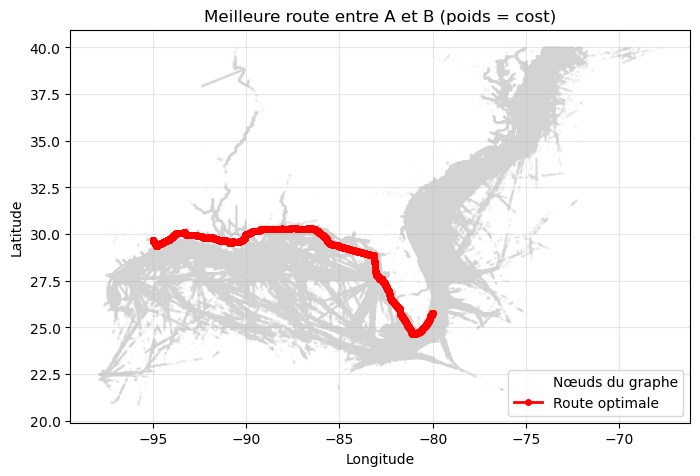

In [13]:

lat_A, lon_A = 29.7, -95.0   # Houston / Galveston
lat_B, lon_B = 25.8, -80.0   # Miami

# Pour visualiser tous les nœuds (à ne pas garder pour toujours, mais pour vérifier)
plot_route(lat_A, lon_A, lat_B, lon_B, weight_attr="cost", sample_bg=len(node_lats))

Start node: 441542, End node: 457129
Path length (nodes): 1738
Total approx distance (km): 642.5
Total cost: 391.252


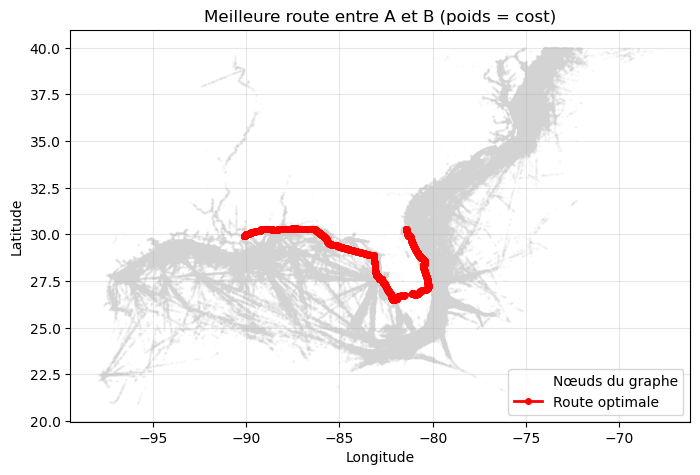

In [14]:

lat_A, lon_A = 29.9, -90.1   # New Orleans
lat_B, lon_B = 30.3, -81.4   # Jacksonville

plot_route(lat_A, lon_A, lat_B, lon_B, weight_attr="cost")

Start node: 349234, End node: 422731
Path length (nodes): 381
Total approx distance (km): 105.6
Total cost: 51.019


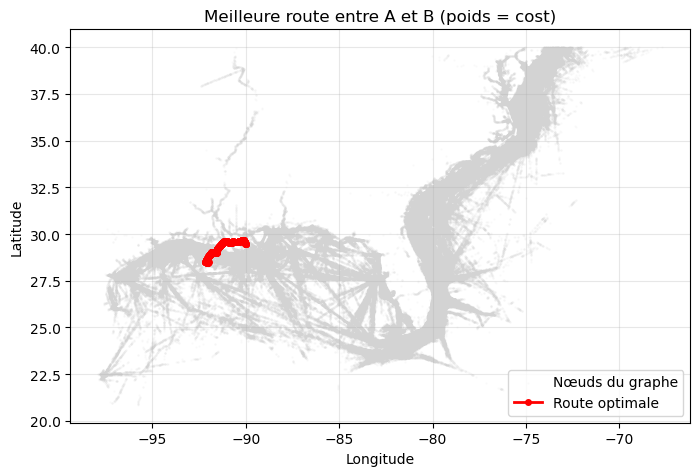

In [15]:
#deux point proches
lat_A, lon_A = 28.5, -92.0
lat_B, lon_B = 29.5, -90.0

plot_route(lat_A, lon_A, lat_B, lon_B, weight_attr="cost")

## Ports : meilleure route entre deux ports

Liste de ports dans la zone focus (CSV `data/ports_focus_zone.csv`).

In [16]:
import pandas as pd

# Charger la liste des ports (à placer dans data/ports_focus_zone.csv)
ports_path = base_dir / "data" / "ports_focus_zone.csv"
if not ports_path.exists():
    ports_path = base_dir / "ports_focus_zone.csv"  # fallback si data/ à la racine
ports_df = pd.read_csv(ports_path)
ports_df = ports_df.set_index("port_id")
print("Ports disponibles:", list(ports_df.index))
display(ports_df)

def best_path_between_ports(port_start_id, port_end_id, weight_attr="cost"):
    """Meilleure route entre deux ports (par id). Utilise nearest_node + Dijkstra."""
    row_start = ports_df.loc[port_start_id]
    row_end = ports_df.loc[port_end_id]
    return best_path_between_points(
        row_start["lat"], row_start["lon"],
        row_end["lat"], row_end["lon"],
        weight_attr=weight_attr
    )

def plot_route_between_ports(port_start_id, port_end_id, weight_attr="cost", sample_bg=200_000):
    """Visualise la meilleure route entre deux ports."""
    row_start = ports_df.loc[port_start_id]
    row_end = ports_df.loc[port_end_id]
    plot_route(
        row_start["lat"], row_start["lon"],
        row_end["lat"], row_end["lon"],
        weight_attr=weight_attr, sample_bg=sample_bg
    )

# Exemple : Houston -> New York
plot_route_between_ports("houston", "new_york", weight_attr="cost") 

Ports disponibles: ['houston', 'galveston', 'new_orleans', 'tampa', 'miami', 'jacksonville', 'savannah', 'charleston', 'norfolk', 'baltimore', 'philadelphia', 'new_york', 'havana', 'veracruz', 'mobile', 'panama_city', 'port_everglades', 'freeport', 'san_juan']


,name,lat,lon
port_id,,,
houston,Houston,29.76,-95.37
galveston,Galveston,29.30,-94.80
new_orleans,New Orleans,29.95,-90.07
tampa,Tampa,27.95,-82.46
miami,Miami,25.77,-80.19
jacksonville,Jacksonville,30.33,-81.66
savannah,Savannah,32.08,-81.09
charleston,Charleston,32.79,-79.93
norfolk,Norfolk,36.85,-76.29


Start node: 436682, End node: 623522
No path. Re-run the cell after loading G (remove long edges + largest component), then cost, nearest_node, this cell.


=== Gulf_to_EastCoast ===
Start node: 284934, End node: 509660


Path length (nodes): 3137
Total approx distance (km): 1192.6
Total cost: 711.626
Total distance ~ 1192.6 km, total cost ~ 711.6
Start node: 284934, End node: 509660
Path length (nodes): 3137
Total approx distance (km): 1192.6
Total cost: 711.626


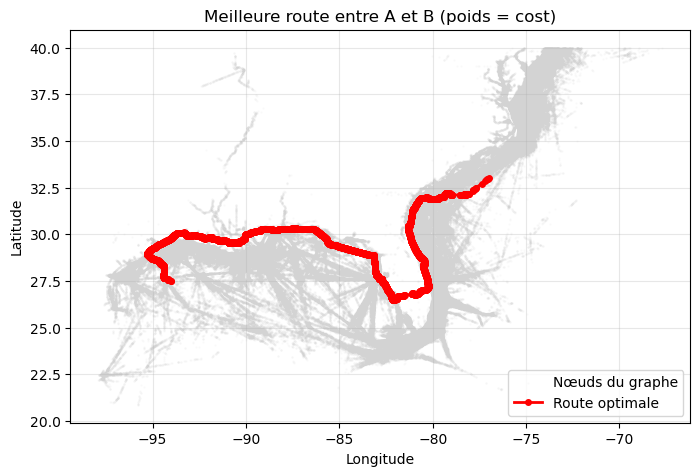

=== Miami_to_NewYork ===
Start node: 219820, End node: 623527
Path length (nodes): 2325
Total approx distance (km): 586.0
Total cost: 358.237
Total distance ~ 586.0 km, total cost ~ 358.2
Start node: 219820, End node: 623527
Path length (nodes): 2325
Total approx distance (km): 586.0
Total cost: 358.237


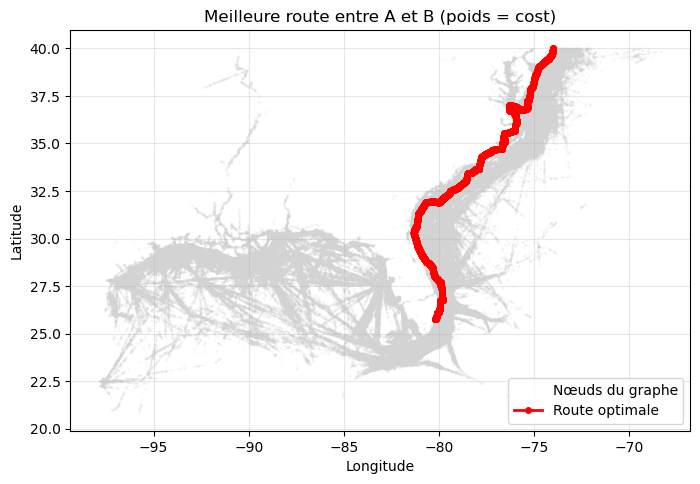

=== Houston_to_PuertoRico ===
Start node: 434055, End node: 128358
No path. Re-run the cell after loading G (remove long edges + largest component), then cost, nearest_node, this cell.
=== Gulf_to_FloridaStraits ===
Start node: 175089, End node: 174022
No path. Re-run the cell after loading G (remove long edges + largest component), then cost, nearest_node, this cell.


In [20]:
scenarios = {
    "Gulf_to_EastCoast": dict(
        lat_A=27.5, lon_A=-94.0,   # large Golfe du Mexique
        lat_B=33.0, lon_B=-77.0    # large Caroline du Nord
    ),
    "Miami_to_NewYork": dict(
        lat_A=25.8, lon_A=-80.2,   # Miami approx
        lat_B=40.7, lon_B=-74.0    # New York approx
    ),
    "Houston_to_PuertoRico": dict(
        lat_A=29.7, lon_A=-95.0,   # Houston/Galveston approx
        lat_B=18.4, lon_B=-66.1    # San Juan, PR approx
    ),
    "Gulf_to_FloridaStraits": dict(
        lat_A=24.5, lon_A=-90.0,   # centre Golfe
        lat_B=24.5, lon_B=-81.5    # Détroit de Floride / Key West approx
    ),
}

for name, cfg in scenarios.items():
    print(f"=== {name} ===")
    lat_A, lon_A = cfg["lat_A"], cfg["lon_A"]
    lat_B, lon_B = cfg["lat_B"], cfg["lon_B"]

    # best_path_between_points ne renvoie que les nœuds + coords
    path_nodes, path_lats, path_lons = best_path_between_points(
        lat_A, lon_A, lat_B, lon_B,
        weight_attr="cost",
    )
    if path_nodes is None:
        continue

    # Recalcule distance totale et coût total le long du chemin
    total_dist_km = 0.0
    total_cost = 0.0
    for a, b in zip(path_nodes[:-1], path_nodes[1:]):
        d = G[a][b]
        total_dist_km += float(d.get("avg_dist_km", 0.0))
        total_cost += float(d.get("cost", 0.0))

    print(f"Total distance ~ {total_dist_km:.1f} km, total cost ~ {total_cost:.1f}")

    # appel sans 'title' (signature actuelle de plot_route)
    plot_route(
        lat_A, lon_A, lat_B, lon_B,
        weight_attr="cost",
    )